# Gradient Descent from Scratch

This notebook implements gradient descent **by hand** for a simple perceptron (specifically an ADALINE — a linear neuron trained with MSE loss).

Goals:
1. See the gradient descent update rule in raw NumPy — no autograd.
2. Visualize the cost function landscape in 3D.
3. Compare with the equivalent PyTorch implementation.

**Prerequisites:** [01_intro_neural_networks.ipynb](../01_intro_neural_networks.ipynb)

## ADALINE: a linear perceptron with gradient descent

**ADALINE** (Adaptive Linear Neuron) is like a perceptron except:
- It uses a **continuous linear output** (no hard threshold during training).
- It minimizes **Mean Squared Error** using gradient descent.
- The gradient has a clean closed-form: $\nabla_w J = X^T (\hat{y} - y)$.

This makes it an ideal model for understanding gradient descent mechanics.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [ ]:
class ADALINE:
    """Linear neuron trained with batch gradient descent (MSE loss)."""

    def __init__(self, lr: float = 0.01, n_iter: int = 50, random_state: int = 1):
        self.lr = lr
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X: np.ndarray, y: np.ndarray) -> "ADALINE":
        rng = np.random.RandomState(self.random_state)
        self.w_ = rng.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.float64(0.0)
        self.losses_: list[float] = []
        self.w_history_: list[np.ndarray] = []

        for _ in range(self.n_iter):
            output = X @ self.w_ + self.b_
            errors = y - output

            # Gradient of MSE w.r.t. weights and bias
            self.w_ -= self.lr * (-X.T @ errors)
            self.b_ -= self.lr * (-errors.sum())

            loss = 0.5 * (errors ** 2).sum()
            self.losses_.append(loss)
            if X.shape[1] == 2:
                self.w_history_.append(self.w_.copy())
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        return np.where(X @ self.w_ + self.b_ >= 0.0, 1, 0)

## Dataset: AND gate

We use the AND logic gate — the simplest linearly separable problem — so we can focus on the mechanics of gradient descent.

In [ ]:
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])

print("X:", X_and.tolist())
print("y:", y_and.tolist())

X: [[0, 0], [0, 1], [1, 0], [1, 1]]
y: [0, 0, 0, 1]


## Training

In [ ]:
model = ADALINE(lr=0.05, n_iter=50, random_state=1)
model.fit(X_and, y_and)

print(f"Final weights: {model.w_}")
print(f"Final bias:    {model.b_:.4f}")
print(f"Predictions:   {model.predict(X_and)}")

Final weights: [0.4242028  0.42248223]
Final bias:    -0.1591
Predictions:   [0 1 1 1]


## Loss curve

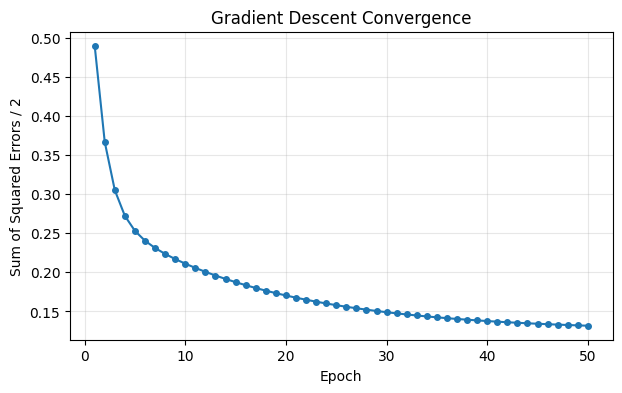

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(model.losses_) + 1), model.losses_, marker="o", markersize=4)
plt.xlabel("Epoch")
plt.ylabel("Sum of Squared Errors / 2")
plt.title("Gradient Descent Convergence")
plt.grid(True, alpha=0.3)
plt.show()

## Cost function landscape (3D)

We fix the bias to its final value and plot cost as a function of `(w₁, w₂)`.

This is a simplification — the real landscape lives in 3D (w₁, w₂, b) — but it gives a clear picture of the "valley" that gradient descent navigates.

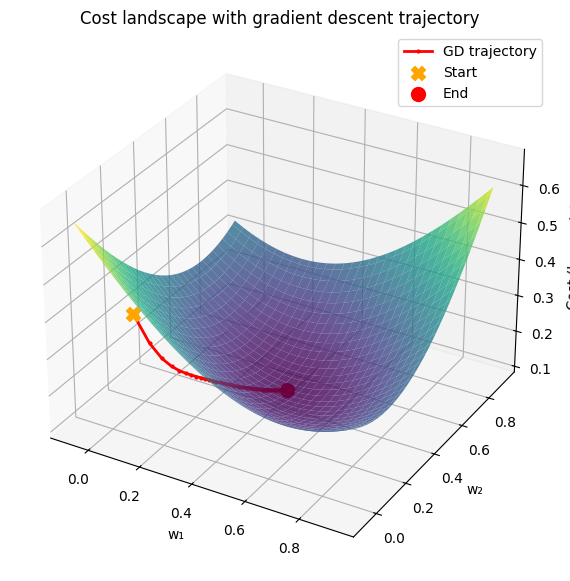

In [ ]:
def cost_for_weights(w1, w2, b, X, y):
    output = X @ np.array([w1, w2]) + b
    return np.log1p(0.5 * ((y - output) ** 2).sum())

b_final = model.b_
w_final = model.w_

w1_range = np.linspace(w_final[0] - 0.5, w_final[0] + 0.5, 60)
w2_range = np.linspace(w_final[1] - 0.5, w_final[1] + 0.5, 60)
W1, W2 = np.meshgrid(w1_range, w2_range)
Cost = np.array([cost_for_weights(w1, w2, b_final, X_and, y_and)
                 for w1, w2 in zip(W1.ravel(), W2.ravel())]).reshape(W1.shape)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(W1, W2, Cost, cmap="viridis", edgecolor="none", alpha=0.8)

# Overlay gradient descent trajectory
w_hist = np.array(model.w_history_)
cost_hist = np.log1p(np.array(model.losses_))
ax.plot(w_hist[:, 0], w_hist[:, 1], cost_hist,
        color="red", marker=".", linewidth=2, markersize=4, label="GD trajectory")
ax.scatter(*w_hist[0], cost_hist[0], color="orange", marker="X", s=100, label="Start")
ax.scatter(*w_hist[-1], cost_hist[-1], color="red", marker="o", s=100, label="End")

ax.set_xlabel("w₁")
ax.set_ylabel("w₂")
ax.set_zlabel("Cost (log scale)")
ax.set_title("Cost landscape with gradient descent trajectory")
ax.legend()
plt.show()

The trajectory shows gradient descent sliding down the cost valley. With a well-chosen learning rate, it converges smoothly to the minimum.

## PyTorch comparison

The same ADALINE in PyTorch requires **zero manual gradient math** — `loss.backward()` + `optimizer.step()` handle everything:

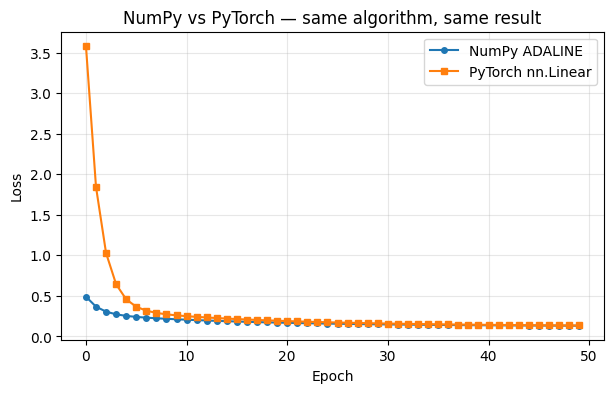

In [ ]:
import torch
import torch.nn as nn

X_t = torch.FloatTensor(X_and)
y_t = torch.FloatTensor(y_and).unsqueeze(1)

torch_model = nn.Linear(2, 1)
optimizer = torch.optim.SGD(torch_model.parameters(), lr=0.05)
criterion = nn.MSELoss(reduction="sum")

losses_pt = []
for epoch in range(50):
    optimizer.zero_grad()
    loss = 0.5 * criterion(torch_model(X_t), y_t)
    loss.backward()
    optimizer.step()
    losses_pt.append(loss.item())

plt.figure(figsize=(7, 4))
plt.plot(model.losses_, label="NumPy ADALINE", marker="o", markersize=4)
plt.plot(losses_pt, label="PyTorch nn.Linear", marker="s", markersize=4)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("NumPy vs PyTorch — same algorithm, same result")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The curves may differ slightly due to different random initialization, but the convergence behavior is identical: both are plain batch gradient descent on MSE loss.

The key takeaway: **PyTorch autograd replaces manual gradient derivation**. You define the forward pass and the loss, and PyTorch computes all gradients automatically via backpropagation.

## What to take away

- Gradient descent updates weights in the direction that reduces the loss: $w \leftarrow w - \eta \nabla_w J$.
- The **learning rate** ($\eta$) controls step size — too large diverges, too small is slow.
- The **cost landscape** for a linear model is convex (one minimum) — but for deep networks it has many local minima.
- PyTorch's autograd eliminates the need for manual gradient derivation, making it trivial to train much more complex models.